# Testiranje spektralnog klasterovanja na sintetičkim podacima

Cilj ove sveske je provera da implementacija spektralnog klasterovanja (iz `src/spectral.py`) ispravno radi na jednostavnom, kontrolisanom primeru, kao i poređenje sa standardnim K-means algoritmom.

## Skup podataka

Koristimo `make_moons` iz scikit-learn biblioteke — dva isprepletana polumeseca, klasičan primer gde K-means ne uspeva da pronađe ispravne klastere zbog nekonveksnog oblika podataka.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

from spectral import spectral_clustering

## Generisanje podataka

Generišemo 300 tačaka raspoređenih u obliku dva polumeseca i dodajemo šum kako bismo simulirali realnije podatke.

In [2]:
X, y_true = make_moons(n_samples=300, noise=0.05, random_state=42)

## Poređenje: K-Means vs Spektralno klasterovanje

Pokrenućemo oba algoritma na istim podacima i vizuelno ćemo uporediti rezultate sa stvarnim klasterima. (za parametar $\sigma$ odabrana je vrednost 0.2, u nastavku će biti detalja oko njegovog izbora).

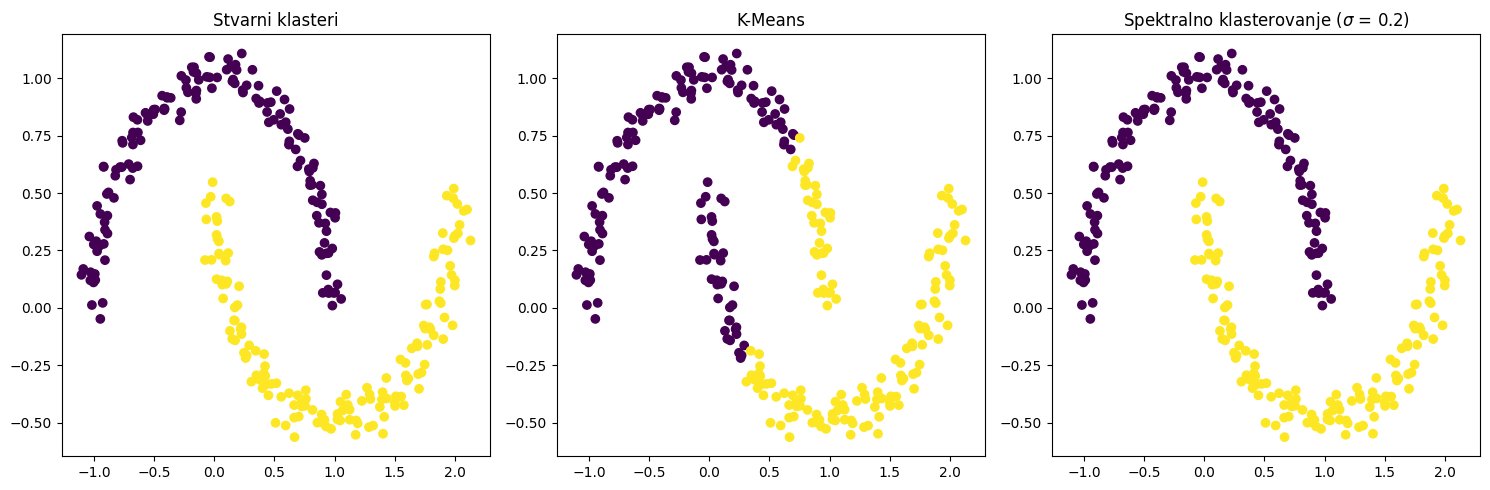

In [3]:
labels_spectral = spectral_clustering(X, k=2, sigma=0.2, normalized=True)
labels_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X).labels_

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis')
axes[0].set_title('Stvarni klasteri')

axes[1].scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap='viridis')
axes[1].set_title('K-Means')

axes[2].scatter(X[:, 0], X[:, 1], c=labels_spectral, cmap='viridis')
axes[2].set_title('Spektralno klasterovanje ($\\sigma$ = 0.2)')

plt.tight_layout()
plt.show()

**Zapažanje:** K-means ne uspeva da razdvoji polumesece ispravno, jer pretpostavlja da su klasteri konveksni. Spektralno klasterovanje uspeva da prati oblik polumeseca, jer radi na strukturi grafa umesto na sirovim koordinatama.

## Uticaj parametra σ (sigma)

Parametar $\sigma$ kontroliše "širinu susedstva" u Gausovom kernelu (širinu Gausovog zvona), i direktno utiče na kvalitet klasterovanja.
Ukoliko je parametar $\sigma$ mali, Gausova funkcija je uža, pa će visoku vrednost sličnosti imati samo tačke koje su međusobno veoma blizu. Sa druge strane, veće vrednosti parametra $\sigma$ dovode do šire Gausove funkcije, čime se i međusobno udaljenijim tačkama dodeljuju veće vrednosti sličnosti.
Testiraćemo nekoliko vrednosti da vidimo kako se rezultat menja.

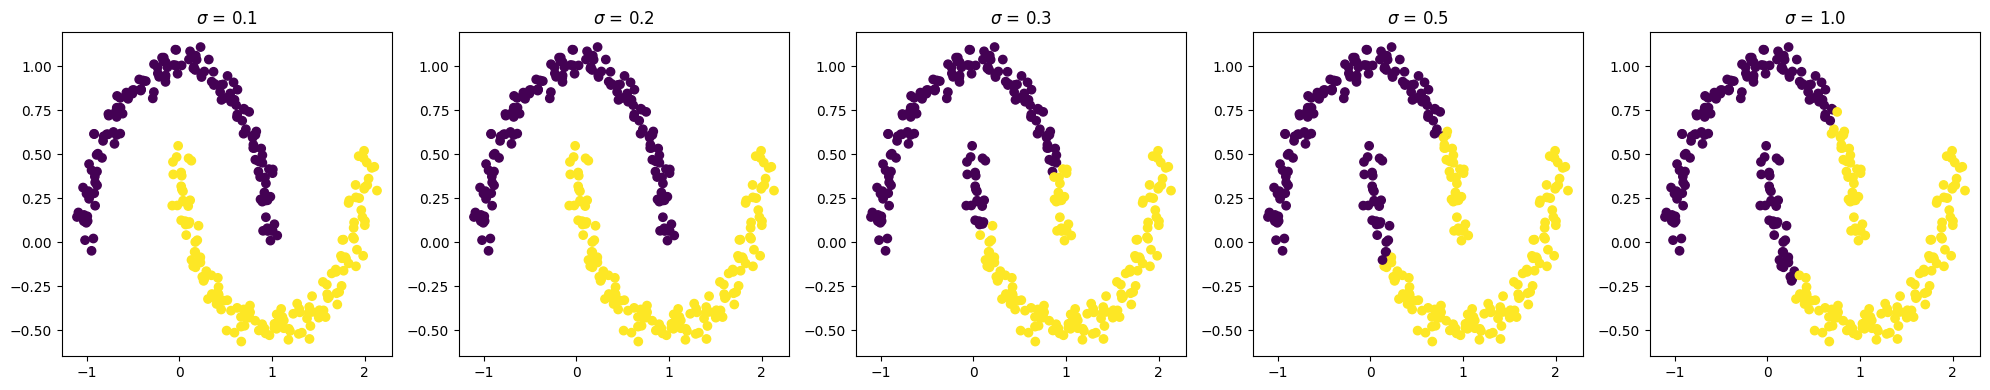

In [4]:
sigma_values = [0.1, 0.2, 0.3, 0.5, 1.0]

fig, axes = plt.subplots(1, len(sigma_values), figsize=(4 * len(sigma_values), 4))

for ax, sigma in zip(axes, sigma_values):
    labels = spectral_clustering(X, k=2, sigma=sigma, normalized=True)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
    ax.set_title(f'$\\sigma$ = {sigma}')

plt.tight_layout()
plt.show()

## Zaključak

- K-means ne uspeva da razdvoji polumesece ispravno, jer pretpostavlja da su klasteri konveksni.
- Spektralno klasterovanje (sa pogodno izabranim parametrom $\sigma$) uspeva da prati oblik polumeseca, jer radi na strukturi grafa umesto na sirovim koordinatama.
- Parametar $\sigma$ je ključan za kvalitet rezultata:
  - $\sigma = 0.5$ i veće vrednosti → rezultat postaje sličan K-means-u (graf postaje previše "gust", gubi se lokalna struktura).
  - $\sigma = 0.3$ → lošije razdvajanje.
  - $\sigma = 0.2$ → najbolje razdvajanje na ovom skupu podataka.

Ova analiza pokazuje da izbor $\sigma$ direktno utiče na kvalitet klasterovanja i da predstavlja pogodan hiperparametar za eksperimentisanje.